In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
import numpy as np
import pandas as pd
import h5py
from tqdm import tqdm
import scipy.io as sio
from scipy import stats
from importlib import reload
from matplotlib import pyplot as plt
import sys
sys.path.append(r'C:\\Users\\scanimage\\Documents\\JJM\\post_cnmfe_analysis')
#sys.path.append('/Users/johnmarshall/Documents/Analysis/PythonAnalysisScripts/post_cmfe_analysis')
import os
os.chdir(r'C:\\Users\\scanimage\\Documents\\JJM\\post_cnmfe_analysis')
import python_utils_jjm as utils_jjm
import python_utils_jjm as utils_jjm
import dlc_utils
from sklearn.preprocessing import MinMaxScaler
import scipy.spatial.distance as dist
import itertools
import math
import warnings
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
#import av
from multiprocessing import Pool
import functools
import glob
#plt.rcParams['animation.ffmpeg_path']='/home/jma819/.conda/envs/caiman/bin/ffmpeg'
warnings.filterwarnings(action='once')
import random
from matplotlib import colors as mcolors

C:\Users\scanimage\AppData\Local\Temp\ipykernel_50532\388325550.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
## helper functions for analysis 

#alignment with ezTrack location tracking data

def alignMiniscopeBehavCamTimestamps(savePath, sessionPath, behavCamFrameRate, miniscopeCamFrameRate):
    #'\\'.join(sessionPath.split(os.sep)[:-1])+'\\timestamp.dat'
    print(sessionPath.split(os.sep)[:-1])
    # load eZ track output and behavior camera timestamps from miniscope software 
    ezTrackOutput = pd.read_csv(sessionPath)
    timestampfile = pd.read_table('\\'.join(sessionPath.split(os.sep)[:-1])+'\\timeStamps.csv', delimiter=',')
    miniscope_timestampfile = pd.read_table('\\'.join(sessionPath.split(os.sep)[:-1])+'\\timeStampsMiniscope.csv', delimiter=',')
    
    timestampfile_td = timestampfile.set_index(pd.to_timedelta(np.linspace(0, (len(timestampfile)-1)*(1/behavCamFrameRate), len(timestampfile)), unit='s'), drop=False)
  
    miniscopetimestamp_td = miniscope_timestampfile.set_index(pd.to_timedelta(np.linspace(0, (len(miniscope_timestampfile)-1)*(1/miniscopeCamFrameRate), len(miniscope_timestampfile)), unit='s'), drop=False)
    
    behavCam_frames = []
    sys_clock_behavCam = []
    #create "key" for aligning miniscope frames to timestamp file
    #then create behavior TD and align
    for msCam_frame in tqdm(range(0, len(miniscopetimestamp_td['Frame Number']))):
        #get sys clock time of each miniscope recorded frame
        #sys_clock_msCam = time_stamps['sysClock'].loc[msCam_frame]
        #find behav cam frame closest to sys clock time of ms frame
        behavCam_frame = list(timestampfile_td.iloc[(timestampfile_td['Time Stamp (ms)']-miniscopetimestamp_td['Time Stamp (ms)'].iloc[msCam_frame]).abs().argsort()[:1]].index)[0]
        #this is the behavCamIndex that is closest to the corresponding miniscope frame 
        behavCam_frames.append(behavCam_frame)
        sys_clock_behavCam.append(timestampfile_td.loc[behavCam_frame]['Time Stamp (ms)'])

    behavCamIdxToAlign = [timestampfile_td.index.get_loc(idx) for idx in behavCam_frames]
    #ezTrackOutput

    miniscopetimestamp_td['closestBehavCamFrameIdx'] = behavCamIdxToAlign

    X_coor=[]
    Y_coor=[]
    Distance_px=[] 

    for i in miniscopetimestamp_td['closestBehavCamFrameIdx'].values:
        X_coor.append(ezTrackOutput.loc[miniscopetimestamp_td['closestBehavCamFrameIdx'].values[i]]['X'])
        Y_coor.append(ezTrackOutput.loc[miniscopetimestamp_td['closestBehavCamFrameIdx'].values[i]]['Y'])
        Distance_px.append(ezTrackOutput.loc[miniscopetimestamp_td['closestBehavCamFrameIdx'].values[i]]['Distance_px'])
    
    miniscopetimestamp_td['X_coor'] = X_coor
    miniscopetimestamp_td['Y_coor'] = Y_coor
    miniscopetimestamp_td['Distance_px'] = Distance_px
    
    return(miniscopetimestamp_td)

## load and do some preprocessing on the CNMFE traces 
def getCellTraces(dir_path, file_name):
    
    CNMFE_file = dir_path+file_name
    ## load cnmfe output and perform some basic adjustments (normalize traces to peak intensity, calculate z score)
    cell_fluorescence = sio.loadmat(CNMFE_file)

    C_timedelta = utils_jjm.create_fluorescence_time_delta(cell_fluorescence['C'])
    C_normalized = C_timedelta.apply(utils_jjm.normalize).set_index(pd.to_timedelta(np.linspace(0, (len(C_timedelta)-1)*(1/20), len(C_timedelta)), unit='s'), drop=True)
    C_z_scored = C_timedelta.apply(stats.zscore).set_index(pd.to_timedelta(np.linspace(0, (len(C_timedelta)-1)*(1/20), len(C_timedelta)), unit='s'), drop=True)
    C_normalized_z_scored = C_normalized.apply(stats.zscore).set_index(pd.to_timedelta(np.linspace(0, (len(C_normalized)-1)*(1/20), len(C_normalized)), unit='s'), drop=True)
    C_normalized_z_scored.drop('msCamFrame', axis=1, inplace=True)

    spatial_components=np.array(cell_fluorescence['A'].todense())

    ##load spatial components by session
    # for v4 dimensions are 600x600 pixels
    com_df, spatial_components = utils_jjm.return_spatial_info(CNMFE_file, 0.6, dims=(600, 600))
    cell_contours, for_dims = utils_jjm.create_contour_layouts(spatial_components, dims=(600, 600))

    C_normalized_z_scored.to_csv(dir_path+file_name.strip("out.mat")+'_C_traces_filtered_origHz.csv')
    com_df.to_csv(dir_path+file_name.strip("out.mat")+'_com_filtered.csv')
    
    print('finished, saved:')
    print(file_name)
    
    return(C_normalized_z_scored, com_df)

In [3]:
#behavior analysis info
savePath = r'F:\\JJM\\miniscope_analysis_CA1\\cnmfe_output\\12_26_58_233_run00\\'
sessionPath = r'F:\\JJM\\miniscope_analysis_CA1\\cnmfe_output\\12_26_58_233_run00\\concactenated_behavCam00behavCam08_LocationOutput.csv'
behavCamFrameRate = 15
miniscopeCamFrameRate = 20 

#cnmfe info 
dir_path = r'F:\\JJM\\miniscope_analysis_CA1\\cnmfe_output\\12_26_58_233_run00\\'
file_name = '13-Nov_19_07_00_out.mat'


behavCamDataAligned = alignMiniscopeBehavCamTimestamps(savePath, sessionPath, behavCamFrameRate, miniscopeCamFrameRate)

C_normalized_z_scored, com = getCellTraces(dir_path, file_name)

['F:', '', 'JJM', '', 'miniscope_analysis_CA1', '', 'cnmfe_output', '', '12_26_58_233_run00', '']


100%|██████████████████████████████████████████████████████████████████████████| 11858/11858 [00:08<00:00, 1368.83it/s]


finished, saved:
13-Nov_19_07_00_out.mat


In [5]:
#display cnmfe data 
C_normalized_z_scored

,1,2,3,4,5,6,7,8,9,10,...,841,842,843,844,845,846,847,848,849,850
0 days 00:00:00,-0.643315,-1.064985,-1.017663,3.015327,-1.101935,-1.131696,-0.172477,-0.171601,-0.183283,-0.222337,...,-0.246843,-0.274444,-0.166494,-0.104623,-0.181159,-0.165539,-0.213587,-0.223218,-0.129784,-0.184575
0 days 00:00:00.050000,-0.652522,-1.064985,-1.018164,3.150337,-1.101935,-1.131696,-0.157516,-0.173187,-0.183339,-0.221253,...,-0.246313,-0.262260,-0.161273,-0.104623,-0.181738,-0.166012,-0.210611,-0.222594,-0.129784,-0.184575
0 days 00:00:00.100000,-0.661571,-1.064985,-1.018660,3.953367,-1.101935,-1.131696,-0.123277,-0.174746,-0.183395,-0.221298,...,-0.246367,-0.253951,-0.161805,-0.104623,-0.182280,-0.166463,-0.211088,-0.222660,-0.129784,-0.184575
0 days 00:00:00.150000,-0.670464,-1.064985,-1.019150,3.869502,-1.101935,-1.131696,-0.126668,-0.176277,-0.183450,-0.220692,...,-0.246416,-0.254936,-0.162298,-0.104623,-0.182788,-0.157499,-0.211546,-0.222724,-0.129784,-0.184575
0 days 00:00:00.200000,-0.679205,-1.064985,-1.019635,3.787079,-1.101935,-1.104736,-0.104052,-0.177781,-0.183504,-0.220353,...,-0.246460,-0.255873,-0.162753,-0.104623,-0.183263,-0.158323,-0.211986,-0.222786,-0.129784,-0.184575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:09:52.650000,-0.314579,0.396848,-0.156034,-0.878513,0.902318,-0.430962,-0.238515,-0.949587,2.111072,-0.206317,...,0.220902,1.868605,-0.146915,-0.104623,-0.186625,-0.176329,-0.145812,-0.224374,-0.129780,-0.177423
0 days 00:09:52.700000,-0.325755,0.381420,-0.165170,-0.879304,0.872219,-0.444310,-0.241751,-0.569534,1.780555,-0.211284,...,4.198420,23.552111,0.393321,-0.104623,-0.187569,-0.176330,-0.193213,-0.224910,-0.129783,-0.180409
0 days 00:09:52.750000,-0.336786,0.366154,-0.174214,-0.880083,0.842572,-0.457404,-0.243694,-0.615204,1.497536,-0.214772,...,1.309166,12.297105,0.184042,-0.104623,-0.188265,-0.176330,-0.211383,-0.225261,-0.129784,-0.182149
0 days 00:09:52.800000,-0.347674,0.351050,-0.183167,-0.880849,0.813370,-0.470248,-0.244859,0.371990,7.202616,-0.217223,...,0.297819,6.358652,0.052727,-0.104623,-0.188778,-0.176330,-0.218349,-0.225492,-0.129784,-0.183162


In [6]:
#tracking data 
behavCamDataAligned.head()

,Frame Number,Time Stamp (ms),Buffer Index,closestBehavCamFrameIdx,X_coor,Y_coor,Distance_px
0 days 00:00:00,0,-44,0,0,88.934350,27.523103,0.000000
0 days 00:00:00.050000,1,9,0,0,88.934350,27.523103,0.000000
0 days 00:00:00.100000,2,58,0,1,88.934350,27.523103,0.000000
0 days 00:00:00.150000,3,108,0,2,100.566523,27.750403,11.634394
0 days 00:00:00.200000,4,159,0,2,100.566523,27.750403,11.634394


In [7]:
# align tracking data to CNMFE for the movies we've analyzed 
CNMFE_aligned = pd.concat([C_normalized_z_scored, behavCamDataAligned.iloc[0:len(C_normalized_z_scored)]], axis=1)
CNMFE_aligned.to_csv(dir_path+file_name.strip("out.mat")+'cellTracesAlignedToTracking.csv')

In [8]:
# for each cell find the peaks above threshold, then get the x,y coordinates of the mouse at those peaks
activity_threshold = 2.5 

cellFiringCoordinates = {}
for cell in list(C_normalized_z_scored.columns):
    coordinatesAtPeak = CNMFE_aligned[['Frame Number', 'closestBehavCamFrameIdx', 'Time Stamp (ms)', 'Y_coor', 'X_coor']].loc[C_normalized_z_scored[cell]>activity_threshold]
    coordinatesAtPeak.to_csv(dir_path+file_name.strip("out.mat")+'cell_'+str(cell)+'_coordinatesabove_'+str(activity_threshold)+'_Zscore_.csv')
    cellFiringCoordinates[cell] = coordinatesAtPeak
    

In [9]:
CNMFE_aligned.head()

,1,2,3,4,5,6,7,8,9,10,...,848,849,850,Frame Number,Time Stamp (ms),Buffer Index,closestBehavCamFrameIdx,X_coor,Y_coor,Distance_px
0 days 00:00:00,-0.643315,-1.064985,-1.017663,3.015327,-1.101935,-1.131696,-0.172477,-0.171601,-0.183283,-0.222337,...,-0.223218,-0.129784,-0.184575,0,-44,0,0,88.934350,27.523103,0.000000
0 days 00:00:00.050000,-0.652522,-1.064985,-1.018164,3.150337,-1.101935,-1.131696,-0.157516,-0.173187,-0.183339,-0.221253,...,-0.222594,-0.129784,-0.184575,1,9,0,0,88.934350,27.523103,0.000000
0 days 00:00:00.100000,-0.661571,-1.064985,-1.018660,3.953367,-1.101935,-1.131696,-0.123277,-0.174746,-0.183395,-0.221298,...,-0.222660,-0.129784,-0.184575,2,58,0,1,88.934350,27.523103,0.000000
0 days 00:00:00.150000,-0.670464,-1.064985,-1.019150,3.869502,-1.101935,-1.131696,-0.126668,-0.176277,-0.183450,-0.220692,...,-0.222724,-0.129784,-0.184575,3,108,0,2,100.566523,27.750403,11.634394
0 days 00:00:00.200000,-0.679205,-1.064985,-1.019635,3.787079,-1.101935,-1.104736,-0.104052,-0.177781,-0.183504,-0.220353,...,-0.222786,-0.129784,-0.184575,4,159,0,2,100.566523,27.750403,11.634394


In [58]:
CNMFE_aligned['Time Stamp (ms)'].values[-1]/1000/60

10.000966666666667

In [60]:
len(CNMFE_aligned['Time Stamp (ms)'].values)

11858

In [61]:
3250/11858

0.27407657277787145

In [65]:
cells_to_plot

[4, 5, 6, 8]

C:\Users\scanimage\AppData\Local\Temp\ipykernel_22172\4246900362.py:32: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


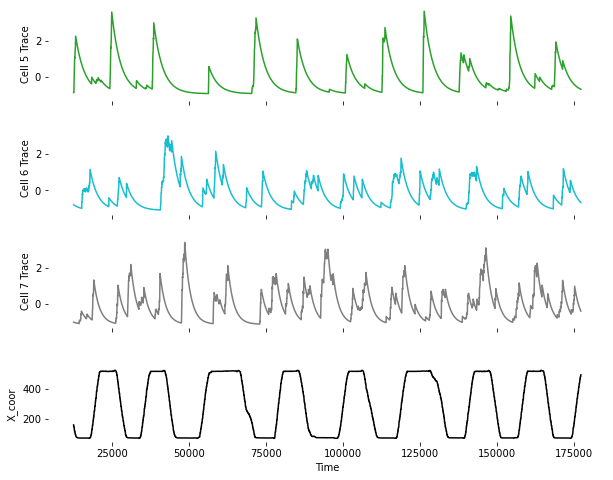

In [54]:
#view trace for cell 
cells_to_plot = [4, 5, 6, 8]
region_to_plot = (250, 3500)
num_cells = len(cells_to_plot)
fig, axs = plt.subplots(num_cells, 1, figsize=(10, 2 * num_cells), sharex=True, sharey=True)  # Adjust figsize as needed

contour_colors = [random.choice(list(mcolors.TABLEAU_COLORS.values())) for _ in range(len(cells_to_plot))]  

for i, ax, color in zip(cells_to_plot, axs, contour_colors):
    ax.plot(CNMFE_aligned['Time Stamp (ms)'][region_to_plot[0]:region_to_plot[1]].values, CNMFE_aligned[i][region_to_plot[0]:region_to_plot[1]],
           color=color)
    ax.set_ylabel(f'Cell {i+1} Trace')
    # Hide the spines (bounding box and axis lines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Create a separate subplot for the X_coor values with its own y-axis scale
ax_x_coor = plt.subplot(num_cells + 1, 1, num_cells + 1)
ax_x_coor.plot(CNMFE_aligned['Time Stamp (ms)'][region_to_plot[0]:region_to_plot[1]].values, CNMFE_aligned['X_coor'][region_to_plot[0]:region_to_plot[1]], color='black', label='X_coor')
ax_x_coor.set_ylabel('X_coor')
ax_x_coor.set_xlabel('Time')

# Hide the spines (bounding box and axis lines) for the X_coor subplot
ax_x_coor.spines['top'].set_visible(False)
ax_x_coor.spines['right'].set_visible(False)
ax_x_coor.spines['bottom'].set_visible(False)
ax_x_coor.spines['left'].set_visible(False)


plt.tight_layout()
plt.savefig('F:\\JJM\\miniscope_analysis_CA1\\figure\\output_traces_and_x_coor_on_subplots.svg', format='svg', bbox_inches='tight', pad_inches=0)

plt.show()

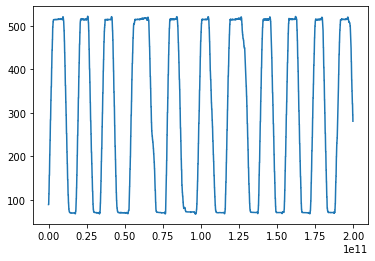

In [22]:
plt.plot(CNMFE_aligned['X_coor'][0:4000])

In [52]:
CNMFE_aligned['Time Stamp (ms)'][region_to_plot[0]:region_to_plot[1]].values

array([ 12620,  12670,  12721, ..., 176977, 177027, 177078], dtype=int64)

In [55]:
cellFiringCoordinates[1]

,Frame Number,closestBehavCamFrameIdx,Time Stamp (ms),Y_coor,X_coor
0 days 00:00:04.400000,88,64,4412,17.151296,350.811525
0 days 00:00:04.450000,89,65,4464,17.151296,350.811525
0 days 00:00:04.500000,90,65,4514,17.151296,350.811525
0 days 00:00:15.700000,314,228,15850,25.645720,462.789562
0 days 00:00:15.750000,315,229,15901,25.645720,462.789562
...,...,...,...,...,...
0 days 00:04:14.050000,5081,3686,257096,11.658002,22.511453
0 days 00:04:14.100000,5082,3687,257148,11.739276,23.209192
0 days 00:04:14.150000,5083,3688,257198,11.860120,23.778928
0 days 00:04:14.200000,5084,3689,257248,11.860120,23.778928
